In [1]:
#importing Libraries and Dataset

import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle
import pefile
import sklearn.ensemble as ek
from sklearn import tree, linear_model
from sklearn.feature_selection import SelectFromModel
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
import seaborn as sns
from keras.metrics import Recall,Precision

import warnings
warnings.filterwarnings("ignore")





In [2]:
#Read the dataset
df = pd.read_csv("C:/Users/PRAVEEN/Desktop/Android_Ransomeware.csv")

In [3]:
from sklearn.metrics import f1_score
import sklearn.metrics


In [4]:
#Dataset Exploration
df

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,2927,10.42.0.151-10.42.0.1-53849-53-17,10.42.0.151,53849,10.42.0.1,53,17,23/08/2017 04:45:14,24707,1,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
392030,2928,10.42.0.151-96.126.100.203-34559-123-17,10.42.0.151,34559,96.126.100.203,123,17,23/08/2017 04:43:31,81388,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
392031,2929,10.42.0.151-10.42.0.1-23177-53-17,10.42.0.151,23177,10.42.0.1,53,17,23/08/2017 04:43:38,61591,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker
392032,2930,10.42.0.151-10.42.0.1-30407-53-17,10.42.0.151,30407,10.42.0.1,53,17,23/08/2017 04:44:56,24831,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WannaLocker


In [5]:
df.describe()

,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,392034.000000,392034.000000,392034.000000,392034.000000,3.920340e+05,392034.000000,392034.000000,3.920340e+05,3.920340e+05,392034.000000,...,392034.000000,3.920340e+05,3.920340e+05,3.920340e+05,3.920340e+05,3.920340e+05,3.920340e+05,3.920340e+05,3.920340e+05,3.920340e+05
mean,1872.127117,38701.627680,5941.135162,8.373332,1.067684e+07,7.078121,8.711813,8.844412e+02,8.354891e+03,233.357069,...,1.737467,-1.108366e+04,1.930192e+05,2.839132e+04,2.227879e+05,1.689341e+05,4.635357e+06,3.513228e+05,4.941648e+06,4.363740e+06
std,1441.683435,18606.610073,15319.609286,4.602725,2.197262e+07,33.434495,80.949869,1.662189e+04,1.099253e+05,572.469765,...,14.554286,3.937015e+06,1.167351e+06,4.912537e+05,1.483669e+06,1.044801e+06,1.511937e+07,3.025004e+06,1.586201e+07,1.476914e+07
min,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,...,0.000000,-1.395062e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,626.000000,34088.000000,80.000000,6.000000,4.402725e+04,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1637.000000,43469.000000,443.000000,6.000000,5.152560e+05,2.000000,1.000000,3.100000e+01,3.100000e+01,31.000000,...,0.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2828.000000,52490.000000,443.000000,6.000000,1.059770e+07,5.000000,4.000000,4.480000e+02,3.830000e+02,333.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,8698.000000,65534.000000,65487.000000,17.000000,1.199997e+08,3632.000000,12820.000000,4.309688e+06,1.851897e+07,20272.000000,...,3211.000000,1.705249e+08,1.074960e+08,5.243613e+07,1.074960e+08,1.074960e+08,1.198864e+08,7.598323e+07,1.198864e+08,1.198864e+08


In [6]:
# Drop a specific column
column_to_drop = 'Unnamed: 0'  
df = df.drop(columns=[column_to_drop])

In [7]:
# Save or view the modified dataset
print(df.head())

                                  Flow ID    Source IP   Source Port  \
0   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211         51023   
1   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211         51023   
2  172.217.12.174-10.42.0.211-443-34259-6  10.42.0.211         34259   
3   172.217.10.74-10.42.0.211-443-55509-6  10.42.0.211         55509   
4   172.217.2.174-10.42.0.211-443-44852-6  10.42.0.211         44852   

   Destination IP   Destination Port   Protocol            Timestamp  \
0   172.217.2.174                443          6  16/06/2017 03:55:47   
1   172.217.2.174                443          6  16/06/2017 03:55:47   
2  172.217.12.174                443          6  16/06/2017 03:55:52   
3   172.217.10.74                443          6  16/06/2017 03:55:53   
4   172.217.2.174                443          6  16/06/2017 03:55:58   

    Flow Duration   Total Fwd Packets   Total Backward Packets  ...  \
0          151054                   6                        8 

In [8]:
# Checking the size of dataframe
from sys import getsizeof
initial_size = getsizeof(df)/(1024.0**3)
print("Size of DataFrame: {} GB".format(initial_size))

Size of DataFrame: 0.3689965717494488 GB


In [9]:
df.isnull().sum()

Flow ID              0
 Source IP           0
 Source Port         0
 Destination IP      0
 Destination Port    0
                    ..
Idle Mean            0
 Idle Std            0
 Idle Max            0
 Idle Min            0
Label                0
Length: 85, dtype: int64

In [10]:
df.Label.value_counts()

Label
SVpeng         54161
PornDroid      46082
Koler          44555
Benign         43091
RansomBO       39859
Charger        39551
Simplocker     36340
WannaLocker    32701
Jisut          25672
Lockerpin      25307
Pletor          4715
Name: count, dtype: int64

In [11]:
# Converting labelled data in categories datatype
df.Label = df.Label.astype('category')
df.Label

0              Benign
1              Benign
2              Benign
3              Benign
4              Benign
             ...     
392029    WannaLocker
392030    WannaLocker
392031    WannaLocker
392032    WannaLocker
392033    WannaLocker
Name: Label, Length: 392034, dtype: category
Categories (11, object): ['Benign', 'Charger', 'Jisut', 'Koler', ..., 'RansomBO', 'SVpeng', 'Simplocker', 'WannaLocker']

In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode the labels
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

# Display encoded classes
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


{'Benign': 0, 'Charger': 1, 'Jisut': 2, 'Koler': 3, 'Lockerpin': 4, 'Pletor': 5, 'PornDroid': 6, 'RansomBO': 7, 'SVpeng': 8, 'Simplocker': 9, 'WannaLocker': 10}


In [13]:
print(df['Label'].value_counts())

Label
8     54161
6     46082
3     44555
0     43091
7     39859
1     39551
9     36340
10    32701
2     25672
4     25307
5      4715
Name: count, dtype: int64


In [14]:
print(df.columns)  # Display the list of column names


Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [15]:
# Converting labelled data in categories datatype
df.Label = df.Label.astype('category')
df.Label

0          0
1          0
2          0
3          0
4          0
          ..
392029    10
392030    10
392031    10
392032    10
392033    10
Name: Label, Length: 392034, dtype: category
Categories (11, int32): [0, 1, 2, 3, ..., 7, 8, 9, 10]

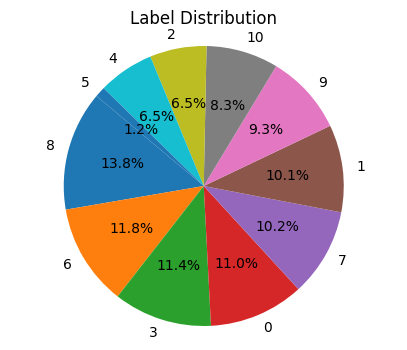

In [16]:
# Import necessary library
import matplotlib.pyplot as plt

# Calculate the value counts of each label
label_counts = df['Label'].value_counts()

# Plot a pie chart
plt.figure(figsize=(5, 4))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
plt.title('Label Distribution')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()


In [17]:
#Column Analysis
df.shape[1]

85

In [18]:
df.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [19]:
df.dtypes

Flow ID                object
 Source IP             object
 Source Port            int64
 Destination IP        object
 Destination Port       int64
                       ...   
Idle Mean             float64
 Idle Std             float64
 Idle Max             float64
 Idle Min             float64
Label                category
Length: 85, dtype: object

In [20]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Identify object columns
object_columns = df.select_dtypes(include=['object']).columns

In [21]:
# Step 2: Apply Label Encoding
label_encoders = {}  # Store encoders for future use
for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Encode the column
    label_encoders[col] = le  # Save the encoder for future reference

# Resulting DataFrame
print("Label Encoded DataFrame:")
print(df)

Label Encoded DataFrame:
        Flow ID   Source IP   Source Port   Destination IP   Destination Port  \
0        151298          14         51023             1328                443   
1        151298          14         51023             1328                443   
2        148227          14         34259             1294                443   
3        142970          14         55509             1247                443   
4        151270          14         44852             1328                443   
...         ...         ...           ...              ...                ...   
392029    26058          13         53849               19                 53   
392030    53062          13         34559             4986                123   
392031    15022          13         23177               19                 53   
392032    17539          13         30407               19                 53   
392033    32839          13         60113               76                443   

  

In [22]:
df.dtypes


Flow ID                 int32
 Source IP              int32
 Source Port            int64
 Destination IP         int32
 Destination Port       int64
                       ...   
Idle Mean             float64
 Idle Std             float64
 Idle Max             float64
 Idle Min             float64
Label                category
Length: 85, dtype: object

<Axes: >

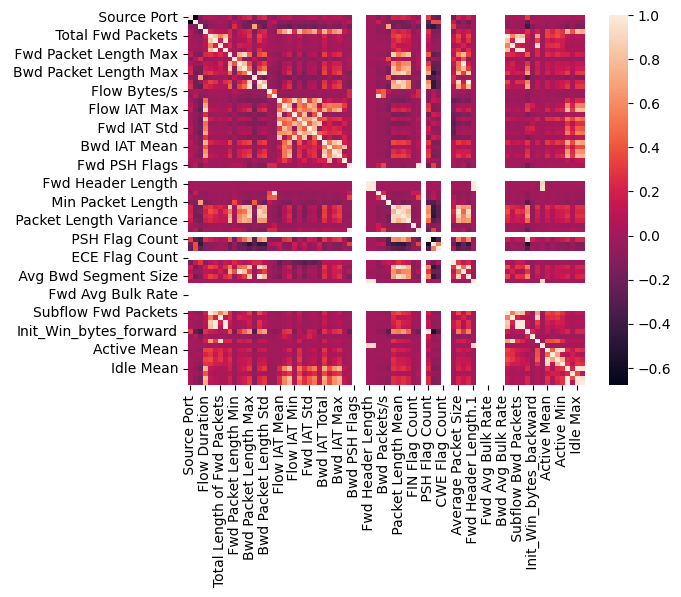

In [23]:
#EDA
# Select only the numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Now you can compute the correlation matrix
sns.heatmap(numeric_df.corr())




In [24]:
# Find columns with a single unique value (zero variance)
zero_variance_columns = df.columns[df.nunique() <= 1].tolist()
print("Zero-variance columns:", zero_variance_columns)


Zero-variance columns: [' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' RST Flag Count', ' CWE Flag Count', ' ECE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [25]:
# List of features to remove
columns_to_remove = [
    ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' RST Flag Count', ' CWE Flag Count', ' ECE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

# Drop these columns from the dataset
df = df.drop(columns=columns_to_remove, errors='ignore')

# Check the shape of the dataset after removal
print("Dataset shape after feature removal:", df.shape)


Dataset shape after feature removal: (392034, 73)


<Axes: >

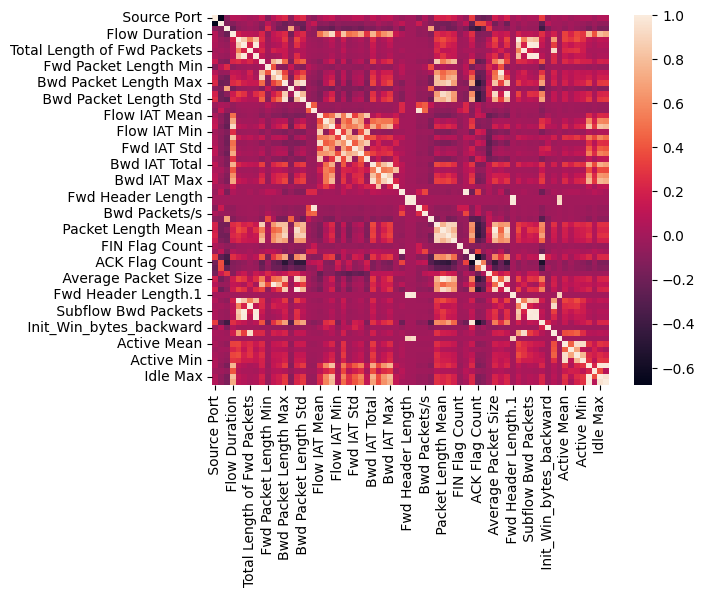

In [26]:
#EDA
# Select only the numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Now you can compute the correlation matrix
sns.heatmap(numeric_df.corr())




In [27]:
# Using VIF to remove highly correlated columns 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Exclude non-numerical and target columns
cols_vif = df.select_dtypes(include=['number']).columns.tolist()
if 'Label' in cols_vif:  # Remove the target column if present
    cols_vif.remove('Label')

print("Columns considered for VIF calculation:", cols_vif)

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = cols_vif

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(df[cols_vif].values, i)
                   for i in range(len(cols_vif))]

print(vif_data)



Columns considered for VIF calculation: ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Cou

In [28]:
#Feature Extraction
def iv_woe(data, target, bins=10, show_woe=False):
    
    #Empty Dataframe
    newDF,woeDF = pd.DataFrame(), pd.DataFrame()
    
    #Extract Column Names
    cols = data.columns
    
    #Run WOE and IV on all the independent variables
    for ivars in cols[~cols.isin([target])]:
        if (data[ivars].dtype.kind in 'bifc') and (len(np.unique(data[ivars]))>10):
            binned_x = pd.qcut(data[ivars], bins,  duplicates='drop')
            d0 = pd.DataFrame({'x': binned_x, 'y': data[target]})
        else:
            d0 = pd.DataFrame({'x': data[ivars], 'y': data[target]})
        d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
        d.columns = ['Cutoff', 'N', 'Events']
        d['% of Events'] = np.maximum(d['Events'], 0.5) / d['Events'].sum()
        d['Non-Events'] = d['N'] - d['Events']
        d['% of Non-Events'] = np.maximum(d['Non-Events'], 0.5) / d['Non-Events'].sum()
        d['WoE'] = np.log(d['% of Events']/d['% of Non-Events'])
        d['IV'] = d['WoE'] * (d['% of Events'] - d['% of Non-Events'])
        d.insert(loc=0, column='Variable', value=ivars)
        print("Information value of " + ivars + " is " + str(round(d['IV'].sum(),6)))
        temp =pd.DataFrame({"Variable" : [ivars], "IV" : [d['IV'].sum()]}, columns = ["Variable", "IV"])
        newDF=pd.concat([newDF,temp], axis=0)
        woeDF=pd.concat([woeDF,d], axis=0)

        #Show WOE Table
        if show_woe == True:
            print(d)
    return newDF, woeDF

In [29]:
df.Label = df.Label.astype('int64')


In [30]:
iv, woe = iv_woe(df, 'Label')



Information value of Flow ID is 0.0
Information value of  Source IP is 0.0
Information value of  Source Port is 0.0
Information value of  Destination IP is 0.0
Information value of  Destination Port is 0.0
Information value of  Protocol is 0.0
Information value of  Timestamp is 0.0
Information value of  Flow Duration is 0.0
Information value of  Total Fwd Packets is 0.0
Information value of  Total Backward Packets is 0.0
Information value of Total Length of Fwd Packets is 0.0
Information value of  Total Length of Bwd Packets is 0.0
Information value of  Fwd Packet Length Max is 0.0
Information value of  Fwd Packet Length Min is 0.0
Information value of  Fwd Packet Length Mean is 0.0
Information value of  Fwd Packet Length Std is 0.0
Information value of Bwd Packet Length Max is 0.0
Information value of  Bwd Packet Length Min is 0.0
Information value of  Bwd Packet Length Mean is 0.0
Information value of  Bwd Packet Length Std is 0.0
Information value of Flow Bytes/s is 0.0
Information 

In [31]:
iv.sort_values(by = 'IV', ascending=False)


,Variable,IV
0,Flow ID,0.0
0,Source IP,0.0
0,Average Packet Size,0.0
0,Down/Up Ratio,0.0
0,URG Flag Count,0.0
...,...,...
0,Flow IAT Std,0.0
0,Flow IAT Mean,0.0
0,Flow Packets/s,0.0
0,Flow Bytes/s,0.0


In [32]:
features = iv.sort_values(by = 'IV', ascending=False)['Variable'][:85].values.tolist()

In [33]:
features

['Flow ID',
 ' Source IP',
 ' Average Packet Size',
 ' Down/Up Ratio',
 ' URG Flag Count',
 ' ACK Flag Count',
 ' PSH Flag Count',
 ' SYN Flag Count',
 'FIN Flag Count',
 ' Packet Length Variance',
 ' Packet Length Std',
 ' Packet Length Mean',
 ' Max Packet Length',
 ' Min Packet Length',
 ' Bwd Packets/s',
 'Fwd Packets/s',
 ' Bwd Header Length',
 ' Avg Fwd Segment Size',
 ' Avg Bwd Segment Size',
 ' Fwd Header Length.1',
 'Active Mean',
 ' Idle Max',
 ' Idle Std',
 'Idle Mean',
 ' Active Min',
 ' Active Max',
 ' Active Std',
 ' min_seg_size_forward',
 'Subflow Fwd Packets',
 ' act_data_pkt_fwd',
 ' Init_Win_bytes_backward',
 'Init_Win_bytes_forward',
 ' Subflow Bwd Bytes',
 ' Subflow Bwd Packets',
 ' Subflow Fwd Bytes',
 ' Fwd Header Length',
 'Fwd PSH Flags',
 ' Bwd IAT Min',
 ' Total Backward Packets',
 ' Fwd Packet Length Std',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Max',
 ' Total Length of Bwd Packets',
 'Total Length of Fwd Packets',
 ' Tota

In [34]:
df.columns = df.columns.str.strip()


In [35]:
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Series([], dtype: int64)


In [36]:
print(df.columns.tolist())


['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Av

In [37]:
# Normalize the column names in the DataFrame
df.columns = df.columns.str.strip().str.lower().str.replace('_', ' ').str.replace('.', '').str.replace('-', ' ')

# Normalize the feature names in the `features` list
normalized_features = [feature.strip().lower().replace('_', ' ').replace('.', '').replace('-', ' ') for feature in features]


In [38]:
for feature in normalized_features:
    matching_columns = [col for col in df.columns if feature in col]
    if matching_columns:
        print(f"Matching columns for '{feature}': {matching_columns}")
    else:
        print(f"No matches found for feature: {feature}")


Matching columns for 'flow id': ['flow id']
Matching columns for 'source ip': ['source ip']
Matching columns for 'average packet size': ['average packet size']
Matching columns for 'down/up ratio': ['down/up ratio']
Matching columns for 'urg flag count': ['urg flag count']
Matching columns for 'ack flag count': ['ack flag count']
Matching columns for 'psh flag count': ['psh flag count']
Matching columns for 'syn flag count': ['syn flag count']
Matching columns for 'fin flag count': ['fin flag count']
Matching columns for 'packet length variance': ['packet length variance']
Matching columns for 'packet length std': ['fwd packet length std', 'bwd packet length std', 'packet length std']
Matching columns for 'packet length mean': ['fwd packet length mean', 'bwd packet length mean', 'packet length mean']
Matching columns for 'max packet length': ['max packet length']
Matching columns for 'min packet length': ['min packet length']
Matching columns for 'bwd packets/s': ['bwd packets/s']
Matc

In [39]:
for feature in normalized_features:
    print(f"Feature: '{feature}'")
    print(f"Closest matches: {[col for col in df.columns if feature[:5] in col[:5]]}")  # Check for partial matches
    print('---')


Feature: 'flow id'
Closest matches: ['flow id', 'flow duration', 'flow bytes/s', 'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min']
---
Feature: 'source ip'
Closest matches: ['source ip', 'source port']
---
Feature: 'average packet size'
Closest matches: ['average packet size']
---
Feature: 'down/up ratio'
Closest matches: ['down/up ratio']
---
Feature: 'urg flag count'
Closest matches: ['urg flag count']
---
Feature: 'ack flag count'
Closest matches: ['ack flag count']
---
Feature: 'psh flag count'
Closest matches: ['psh flag count']
---
Feature: 'syn flag count'
Closest matches: ['syn flag count']
---
Feature: 'fin flag count'
Closest matches: ['fin flag count']
---
Feature: 'packet length variance'
Closest matches: ['packet length mean', 'packet length std', 'packet length variance']
---
Feature: 'packet length std'
Closest matches: ['packet length mean', 'packet length std', 'packet length variance']
---
Feature: 'packet length mean'
Closest matches:

In [40]:
# Create a dictionary to map mismatched features to the correct column names
manual_mapping = {
    'init win bytes backward': 'init_win_bytes_backward',  # Example mapping
    'flow iat min': 'flow iat min',
    # Add more mappings as necessary
}

# Apply the manual mapping for unmatched features
final_features = [manual_mapping.get(feature, feature) for feature in normalized_features]


In [41]:
for feature in final_features:
    matching_columns = [col for col in df.columns if feature in col]
    if matching_columns:
        print(f"Matching columns for '{feature}': {matching_columns}")
    else:
        print(f"No matches found for feature: {feature}")


Matching columns for 'flow id': ['flow id']
Matching columns for 'source ip': ['source ip']
Matching columns for 'average packet size': ['average packet size']
Matching columns for 'down/up ratio': ['down/up ratio']
Matching columns for 'urg flag count': ['urg flag count']
Matching columns for 'ack flag count': ['ack flag count']
Matching columns for 'psh flag count': ['psh flag count']
Matching columns for 'syn flag count': ['syn flag count']
Matching columns for 'fin flag count': ['fin flag count']
Matching columns for 'packet length variance': ['packet length variance']
Matching columns for 'packet length std': ['fwd packet length std', 'bwd packet length std', 'packet length std']
Matching columns for 'packet length mean': ['fwd packet length mean', 'bwd packet length mean', 'packet length mean']
Matching columns for 'max packet length': ['max packet length']
Matching columns for 'min packet length': ['min packet length']
Matching columns for 'bwd packets/s': ['bwd packets/s']
Matc

In [42]:
print(df.columns.tolist())


['flow id', 'source ip', 'source port', 'destination ip', 'destination port', 'protocol', 'timestamp', 'flow duration', 'total fwd packets', 'total backward packets', 'total length of fwd packets', 'total length of bwd packets', 'fwd packet length max', 'fwd packet length min', 'fwd packet length mean', 'fwd packet length std', 'bwd packet length max', 'bwd packet length min', 'bwd packet length mean', 'bwd packet length std', 'flow bytes/s', 'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min', 'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max', 'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std', 'bwd iat max', 'bwd iat min', 'fwd psh flags', 'fwd header length', 'bwd header length', 'fwd packets/s', 'bwd packets/s', 'min packet length', 'max packet length', 'packet length mean', 'packet length std', 'packet length variance', 'fin flag count', 'syn flag count', 'psh flag count', 'ack flag count', 'urg flag count', 'down/up ratio', 'av

In [43]:
# Ensure all features are numeric
X = df.drop('label',axis=1)
y = df['label']


In [44]:
#Split dataset
randomseed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randomseed)

In [45]:
print(X_test.shape[0] + X_train.shape[0])
print('Training labels shape:', y_train.shape)
print('Test labels shape:', y_test.shape)
print('Training features shape:', X_train.shape)
print('Test features shape:', X_test.shape)

392034
Training labels shape: (313627,)
Test labels shape: (78407,)
Training features shape: (313627, 72)
Test features shape: (78407, 72)


In [46]:
# Ensure labels are numeric
y_train = np.array(y_train).astype(int)
y_test = np.array(y_test).astype(int)


In [47]:
# Reshape labels for binary classification
Y_train = np.expand_dims(y_train, axis=1)  # Shape should be (None, 1)
Y_test = np.expand_dims(y_test, axis=1)

In [48]:
from sklearn.preprocessing import StandardScaler

# Convert DataFrame to numpy arrays and standardize
scaler = StandardScaler()

# Flatten the features for scaling (2D format)
X_train_scaled = scaler.fit_transform(X_train.values.reshape(X_train.shape[0], -1))  # Flatten for scaling
X_test_scaled = scaler.transform(X_test.values.reshape(X_test.shape[0], -1))


In [49]:

print('Scaled Training features shape:', X_train_scaled.shape)
print('Scaled Test features shape:', X_test_scaled.shape)


Scaled Training features shape: (313627, 72)
Scaled Test features shape: (78407, 72)


In [50]:
# Compute class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class Weights:", class_weight_dict)

Class Weights: {0: 0.8263258014881015, 1: 0.9026640110981274, 2: 1.3868832305937082, 3: 0.8006836882402049, 4: 1.4143333228109258, 5: 7.580841652365184, 6: 0.7733412567686192, 7: 0.8941993242761629, 8: 0.6570388868171971, 9: 0.980823057365078, 10: 1.0868165531198237}


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import time

In [52]:


# Define the number of classes
num_classes = len(set(y_train))  # Ensure y_train contains integer-encoded labels

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

# Build the model
model = Sequential()
model.add(Dense(72, input_dim=72, activation='relu', kernel_initializer='random_uniform', bias_initializer='zeros'))
model.add(Dense(144, activation='relu'))

model.add(Dropout(0.2))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.3))  # Lower dropout rate
model.add(Dense(num_classes, activation='softmax'))  # Output layer with 'softmax' for multi-class

# Compile the model
adam = Adam(learning_rate=0.001)  # Lower learning rate
model.compile(optimizer=adam, 
              loss='categorical_crossentropy',  # Change to 'categorical_crossentropy' for multi-class
              metrics=['accuracy', Recall(), Precision()])

# Set early stopping
callbacks = [EarlyStopping(monitor='val_loss', patience=100)]  # Lower patience

# Train the model with class weights
st = time.time()
history = model.fit(X_train_scaled, y_train_one_hot,  # Use one-hot encoded labels
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_test_scaled, y_test_one_hot),  # Use one-hot encoded labels
                    class_weight=class_weight_dict,  # Ensure class weights are adjusted for multi-class
                    callbacks=callbacks)

print('Train time: ', time.time() - st, 'sec.')


# Time
import time
st = time.time()
model.fit(X_train_scaled,  y_train_one_hot)
print('Train time: ', time.time()-st, 'sec.')


Epoch 1/100
9801/9801 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.5615 - loss: 1.0639 - precision: 0.7249 - recall: 0.4106 - val_accuracy: 0.7376 - val_loss: 0.6198 - val_precision: 0.8416 - val_recall: 0.6457
Epoch 2/100
9801/9801 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.7247 - loss: 0.6291 - precision: 0.8161 - recall: 0.6423 - val_accuracy: 0.7625 - val_loss: 0.5452 - val_precision: 0.8522 - val_recall: 0.6897
Epoch 3/100
9801/9801 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.7510 - loss: 0.5646 - precision: 0.8330 - recall: 0.6791 - val_accuracy: 0.7837 - val_loss: 0.4958 - val_precision: 0.8543 - val_recall: 0.7188
Epoch 4/100
9801/9801 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.7635 - loss: 0.5352 - precision: 0.8411 - recall: 0.6966 - val_accuracy: 0.7953 - val_loss: 0.4783 - val_precision: 0.8727 - val_recall: 0.7211
Epoch 5/100
9801/9801 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.7768 - loss: 0.5076 - precision: 0.8471 - recall: 0.7132 - val_accuracy: 0

In [53]:
#Testing performance of model
st = time.time()
y_pred = model.predict(X_test_scaled)
print('Test time: ', time.time()-st, 'sec.')


2451/2451 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Test time:  3.788156032562256 sec.


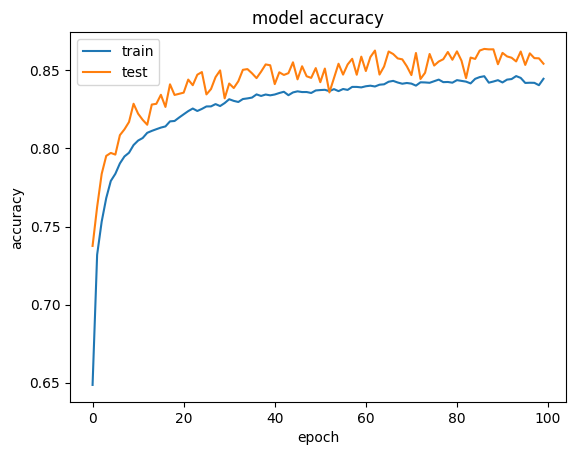

In [54]:
import matplotlib.pyplot as plt
#Accuracy, Loss, Precision, Recall, 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


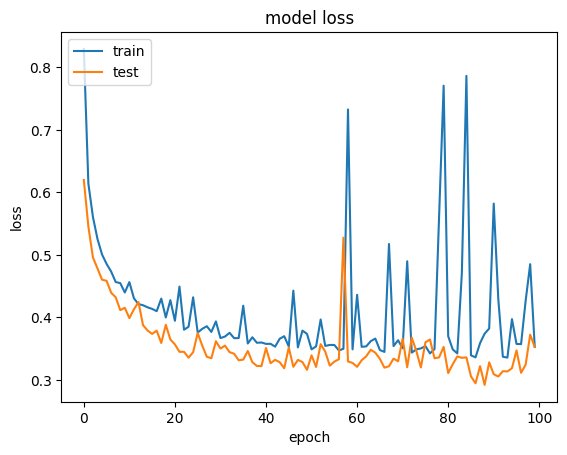

In [55]:

# # # summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


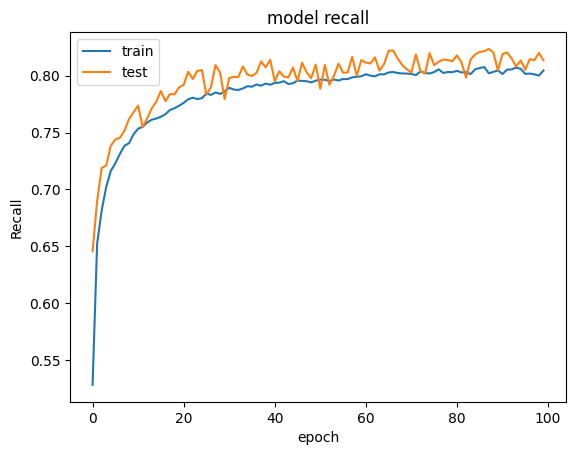

In [56]:
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('model recall')
plt.ylabel('Recall')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


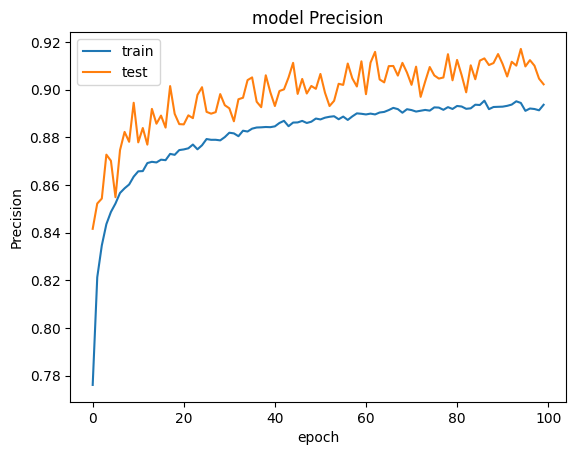

In [57]:
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('model Precision')
plt.ylabel('Precision')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set (using the model)
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the class with the highest probability

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred_classes)

# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred_classes, average='macro')  # 'macro' for unweighted mean
recall = recall_score(y_test, y_pred_classes, average='macro')        # 'macro' for unweighted mean
f1 = f1_score(y_test, y_pred_classes, average='macro')                # 'macro' for unweighted mean

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1 Score (macro): {f1:.4f}")


2451/2451 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.8582
Precision (macro): 0.8701
Recall (macro): 0.8492
F1 Score (macro): 0.8561


In [59]:


from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Calculate class-wise accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Print the accuracy for each class
for i, accuracy in enumerate(class_accuracies):
    print(f"Class {i} accuracy: {accuracy:.2f}%")


Class 0 accuracy: 0.99%
Class 1 accuracy: 0.90%
Class 2 accuracy: 0.81%
Class 3 accuracy: 0.95%
Class 4 accuracy: 0.90%
Class 5 accuracy: 0.75%
Class 6 accuracy: 0.88%
Class 7 accuracy: 0.72%
Class 8 accuracy: 0.76%
Class 9 accuracy: 0.88%
Class 10 accuracy: 0.80%


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1 score for each class
precision_per_class = precision_score(y_test, y_pred_classes, average=None)
recall_per_class = recall_score(y_test, y_pred_classes, average=None)
f1_per_class = f1_score(y_test, y_pred_classes, average=None)

# Print the results
for i in range(len(precision_per_class)):
    print(f"Class {i} - Precision: {precision_per_class[i]:.2f}, Recall: {recall_per_class[i]:.2f}, F1 Score: {f1_per_class[i]:.2f}")


Class 0 - Precision: 0.99, Recall: 0.99, F1 Score: 0.99
Class 1 - Precision: 0.69, Recall: 0.90, F1 Score: 0.78
Class 2 - Precision: 0.84, Recall: 0.81, F1 Score: 0.82
Class 3 - Precision: 0.87, Recall: 0.95, F1 Score: 0.91
Class 4 - Precision: 0.89, Recall: 0.90, F1 Score: 0.89
Class 5 - Precision: 0.92, Recall: 0.75, F1 Score: 0.83
Class 6 - Precision: 0.93, Recall: 0.88, F1 Score: 0.90
Class 7 - Precision: 0.87, Recall: 0.72, F1 Score: 0.79
Class 8 - Precision: 0.81, Recall: 0.76, F1 Score: 0.79
Class 9 - Precision: 0.82, Recall: 0.88, F1 Score: 0.85
Class 10 - Precision: 0.93, Recall: 0.80, F1 Score: 0.86


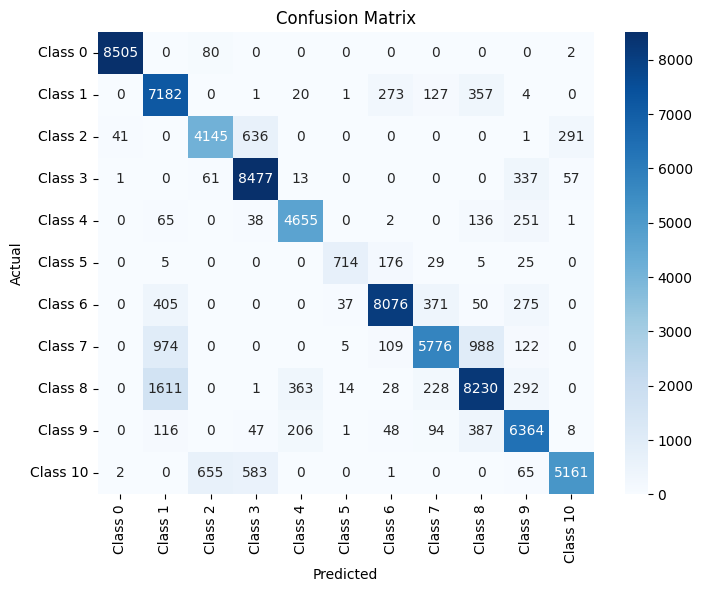

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=[f'Class {i}' for i in range(num_classes)], 
            yticklabels=[f'Class {i}' for i in range(num_classes)])

# Add labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


2451/2451 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


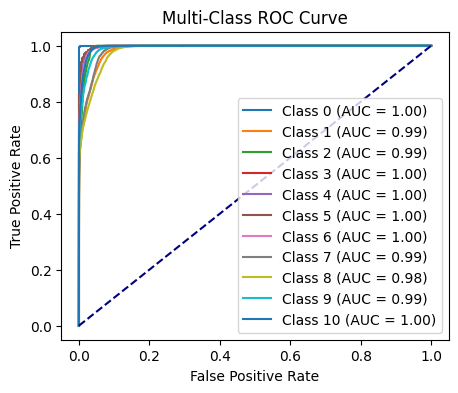

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming you have already converted y_train and y_test to one-hot encoded labels
# If not, you can convert them using label_binarize
y_test_bin = label_binarize(y_test, classes=range(num_classes))  # Convert labels to binary matrix (one-hot)

# Get the model's predictions for each class
y_pred_keras = model.predict(np.asarray(X_test_scaled).astype(np.float32))

# Initialize plot
plt.figure(figsize=(5, 4))

# For each class, compute the ROC curve
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_keras[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve for each class
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot the "no skill" ROC curve (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

# Add labels, title, and legend
plt.title('Multi-Class ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

# Show the plot
plt.show()


In [63]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 72)                  │           5,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 144)                 │          10,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 144)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          14,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │           1,111 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,139 (367.73 KB)

 Trainable params: 31,379 (122.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,760 (245.16 KB)

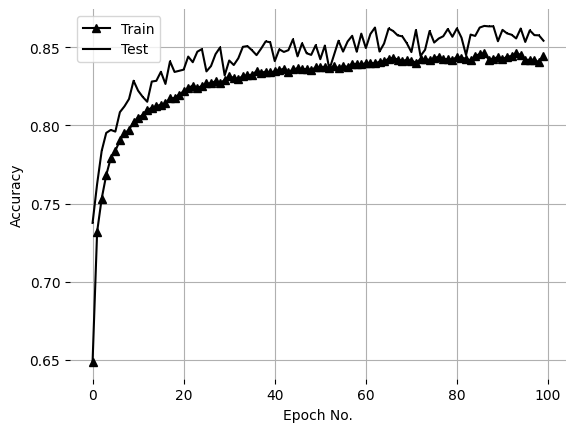

In [64]:
from cycler import cycler
# Create cycler object. Use any styling from above you please
monochrome = (cycler('color', ['k']) * cycler('linestyle', ['-', '--', ':', '-.']) * cycler('marker', ['^',',', '.']))
fig, ax = plt.subplots(1,1)
ax.set_prop_cycle(monochrome)
ax.grid()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch No.')
plt.legend(['Train', 'Test'], loc='best')
plt.show()
